# Posterior for K. pneumoniae local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from Bio import Phylo
import seaborn as sns
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.neural_nets import posterior_nn
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform
from LeaveLengthOut_NN import LeaveLengthOut_NN

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load K. pneumoniae gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/klebsiella/klebsiella_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

         ___________________________ 6K89HyFBbDwXdwchwqkADP-GCA_019928025
       _|
      | |    _______________________ o3RhFr5btpW7DTfXtue7c5-GCA_019927485
      | |___|
      |     |_______________________ spc6uUrrN2v9jc6UX7DiRy-GCA_019930485
     ,|
     ||       ______________________ w7tJjbUBPZePmFG3NDmzp5-GCA_019928665
     ||  ____|
     || |    |______________________ xaAjEgiWJ6VpYxwkH9LSk9-GCA_019928595
     ||_|
     |  |     ______________________ nSFymoP4AQEsMnKgY82Syr-GCA_019928285
     |  |____|
     |       |______________________ 1k2mmojDYi7HwWwByEje5E-GCA_019928115
     |
     |        ______________________ 5rzNEErwwW9sBnVoSPeLxJ-GCA_019927845
     |   ____|
     |  |    |______________________ 7iUximMjZSb8j3oo5o3GyN-GCA_019927325
  ___|  |
 |   | _|     ______________________ 19UUUUQvAAyHsrWsprUbF7-GCA_019927745
 |   || |____|
 |   || |    |______________________ pVybzfzKoAGacFHHpXyyko-GCA_019928045
 |   || |
 |   || |     ______________________ bKMwQNtdgmF9bNgpmS6F

In [3]:
drop_col = range(16, 32)

In [4]:
x_obs_8000_df1 = pd.read_csv("../data/klebsiella/summary_stats/rand_seg8000_i.csv", header=None)
x_obs_8000_df2 = pd.read_csv("../data/klebsiella/summary_stats/rand_seg8000_ii.csv", header=None)
x_obs_np = np.concatenate((x_obs_8000_df1.to_numpy(), x_obs_8000_df2.to_numpy()), axis=0)
x_obs_np = np.delete(x_obs_np, drop_col, axis=1)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([2000, 30]), torch.float32)

In [5]:
x_obs_rand_df = pd.read_csv("../data/klebsiella/summary_stats/rand_seg_2.csv", header=None)
x_obs_np2 = x_obs_rand_df.to_numpy()
x_obs_np2 = np.delete(x_obs_np2, drop_col, axis=1)
x_obs_torch2 = torch.tensor(x_obs_np2, device=torch_device)
x_obs_torch2 = x_obs_torch2.to(torch.float32)
x_obs_torch2.shape, x_obs_torch2.dtype

(torch.Size([2000, 30]), torch.float32)

### Delete observations with no signal

In [6]:
no_signal_id = np.where(x_obs_np[:, 17] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((0,), array([], dtype=int64))

In [7]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((2000, 30), torch.Size([2000, 30]), torch.float32)

In [8]:
no_signal_id2 = np.where(x_obs_np2[:, 17] == 0)[0]
no_signal_id2.shape, no_signal_id2[:10]

((0,), array([], dtype=int64))

In [9]:
x_obs_np2 = np.delete(x_obs_np2, no_signal_id2, axis=0)
x_obs_torch2 = torch.tensor(x_obs_np2, device=torch_device)
x_obs_torch2 = x_obs_torch2.to(torch.float32)
x_obs_np2.shape, x_obs_torch2.shape, x_obs_torch2.dtype

((2000, 30), torch.Size([2000, 30]), torch.float32)

## Load simulation data

In [10]:
theta1 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x1.csv', delimiter=",")
nrow1 = x1.shape[0]

theta2 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x2.csv', delimiter=",")
nrow2 = x2.shape[0]

theta3 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x3.csv', delimiter=",")
nrow3 = x3.shape[0]

theta4 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x4.csv', delimiter=",")
nrow4 = x4.shape[0]

theta5 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x5.csv', delimiter=",")
nrow5 = x5.shape[0]

theta6 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta6.csv', delimiter=",")
x6 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x6.csv', delimiter=",")
nrow6 = x6.shape[0]

theta7 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta7.csv', delimiter=",")
x7 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x7.csv', delimiter=",")
nrow7 = x7.shape[0]

theta8 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta8.csv', delimiter=",")
x8 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x8.csv', delimiter=",")
nrow8 = x8.shape[0]

theta9 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta9.csv', delimiter=",")
x9 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x9.csv', delimiter=",")
nrow9 = x9.shape[0]

theta10 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta10.csv', delimiter=",")
x10 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x10.csv', delimiter=",")
nrow10 = x10.shape[0]

theta11 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta11.csv', delimiter=",")
x11 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x11.csv', delimiter=",")
nrow11 = x11.shape[0]

theta12 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta12.csv', delimiter=",")
x12 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x12.csv', delimiter=",")
nrow12 = x12.shape[0]

theta13 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta13.csv', delimiter=",")
x13 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x13.csv', delimiter=",")
nrow13 = x13.shape[0]

theta14 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta14.csv', delimiter=",")
x14 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x14.csv', delimiter=",")
nrow14 = x14.shape[0]

theta15 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta15.csv', delimiter=",")
x15 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x15.csv', delimiter=",")
nrow15 = x15.shape[0]

theta16 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta16.csv', delimiter=",")
x16 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x16.csv', delimiter=",")
nrow16 = x16.shape[0]

theta17 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta17.csv', delimiter=",")
x17 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x17.csv', delimiter=",")
nrow17 = x17.shape[0]

theta18 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta18.csv', delimiter=",")
x18 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x18.csv', delimiter=",")
nrow18 = x18.shape[0]

theta19 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta19.csv', delimiter=",")
x19 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x19.csv', delimiter=",")
nrow19 = x19.shape[0]

theta20 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/theta20.csv', delimiter=",")
x20 = np.loadtxt('../data/klebsiella/ClonalOrigin_sim/x20.csv', delimiter=",")
nrow20 = x20.shape[0]

x = np.vstack([x1,  x2,  x3,  x4,  x5,  x6,  x7,  x8,  x9,  x10,
               x11, x12, x13, x14, x15, x16, x17, x18, x19, x20])
x = np.delete(x, drop_col, axis=1)
theta = np.vstack([theta1[:nrow1], theta2[:nrow2], theta3[:nrow3], theta4[:nrow4], theta5[:nrow5],
                   theta6[:nrow6], theta7[:nrow7], theta8[:nrow8], theta9[:nrow9], theta10[:nrow10],
                   theta11[:nrow11], theta12[:nrow12], theta13[:nrow13], theta14[:nrow14], theta15[:nrow15],
                   theta16[:nrow16], theta17[:nrow17], theta18[:nrow18], theta19[:nrow19], theta20[:nrow20]])

theta = theta[:50000, :]
x = x[:50000, :]

print(theta.shape, x.shape)

(50000, 3) (50000, 30)


In [11]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [12]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch2.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(30):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch2[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 17 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch2[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 0 is outside the range of simulated data.
Observation 2 is outside the range of simulated data.
Observation 3 is outside the range of simulated data.
Observation 4 is outside the range of simulated data.
Observation 29 is outside the range of simulated data.
Observation 52 is outside the range of simulated data.
Observation 55 is outside the range of simulated data.
Observation 62 is outside the range of simulated data.
Observation 77 is outside the range of simulated data.
Observation 80 is outside the range of simulated data.
Observation 84 is outside the range of simulated data.
Observation 107 is outside the range of simulated data.
Observation 145 is outside the range of simulated data.
Observation 146 is outside the range of simulated data.
Observation 149 is outside the range of simulated data.
Observation 182 is outside the range of simulated data.
Observation 195 is outside the range of simulated data.
Observation 246 is outside the range of simulated data.
Observa

In [13]:
len(ignore_indices), len(no_segregation), len(out_stats)

(148, 0, 148)

In [14]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [15]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [16]:
for i in range(30):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 47
Index 9: 3
Index 10: 0
Index 11: 0
Index 12: 54
Index 13: 85
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 50
Index 23: 7
Index 24: 0
Index 25: 52
Index 26: 1
Index 27: 0
Index 28: 1
Index 29: 0


## NPE

### Create prior to pass range knowledge to NPE

In [17]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.05]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.05]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

### Using all simulations

In [18]:
embedding_net = LeaveLengthOut_NN(
    input_dim=30,
    num_hiddens=128,
    num_hidden_layers=1,
    num_outputs=2)
neural_posterior = posterior_nn(
    model="nsf",
    embedding_net=embedding_net,
    hidden_features=30,
    num_transforms=8,
    num_bins=5,
    z_score_theta="independent",
    z_score_x="independent"
)

In [19]:
seed = 100
num_posterior_samples=1000

inference = NPE_C(density_estimator=neural_posterior, device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [20]:
# density_estimator = inference.append_simulations(theta, x).train(
#     max_num_epochs=500,
#     training_batch_size=100,
#     learning_rate=0.0001,
#     stop_after_epochs=20,
#     clip_max_norm=None
# )
# posterior = inference.build_posterior(density_estimator)

In [21]:
# fig, axes = plot_summary(
#     inference, 
#     tags=["training_loss", "validation_loss"], 
#     figsize=(8, 4)
# )
# plt.title("Training and Validation Loss")
# plt.show()

### Save the trained NPE

In [22]:
save_path = "../data/klebsiella/trained_npe_posterior.pt"

# torch.save(
#     {
#         "posterior": posterior,
#         "sbi_version": sbi.__version__,
#         "seed": seed,
#         "learning_rate": 0.0001,
#         "max_num_epochs": 500,
#     },
#     save_path,
# )

In [23]:
checkpoint = torch.load(save_path, map_location="cpu")
posterior = checkpoint["posterior"]

C:\Users\u2008181\AppData\Local\Temp\ipykernel_28768\1569981112.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location="cpu")


### Plug in observations from real genes to get posterior

In [24]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(2000, 1000, 3)

In [25]:
for i in range(x_obs_torch.shape[0]):
    # if i in ignore_indices:
    #     continue

    theta_post_torch = posterior.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                        show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


### Plot bar plots by position

In [29]:
gene_info = pd.read_csv("../data/klebsiella/rand_seg_info_updated.csv")
x_obs_info_table = gene_info.loc[4000:, :]
x_obs_info_table

,Gene_Length,Start_pos,End_pos,Alignment,Gene_Length_raw,Start_pos_raw,End_pos_raw
4000,8000,854257,862256,True,10061,1064745,1074805
4001,8000,736686,744685,True,8373,901384,909756
4002,8000,3428645,3436644,True,8001,4879275,4887275
4003,8000,1586716,1594715,True,8364,2031354,2039717
4004,8000,2169620,2177619,True,8420,3094426,3102845
...,...,...,...,...,...,...,...
5995,8000,529936,537935,True,8130,630615,638744
5996,8000,760397,768396,True,9100,925773,934872
5997,8000,1944445,1952444,True,8009,2683160,2691168
5998,8000,484724,492723,True,21148,570450,591597


In [30]:
from hotspot_DoG import DoGHotspotDetector

In [31]:
gene_starts = np.delete(x_obs_info_table['Start_pos_raw'].values, no_signal_id)
gene_ends = np.delete(x_obs_info_table['End_pos_raw'].values, no_signal_id)
ord_start_pos = np.argsort(gene_starts)
ord_end_pos = np.argsort(gene_ends)
print(np.all(ord_start_pos == ord_end_pos))

True


Detected hotspot segments:
  4.44-4.45 Mb; 8 genes; peak P=1.000; peak enrichment=2.06x


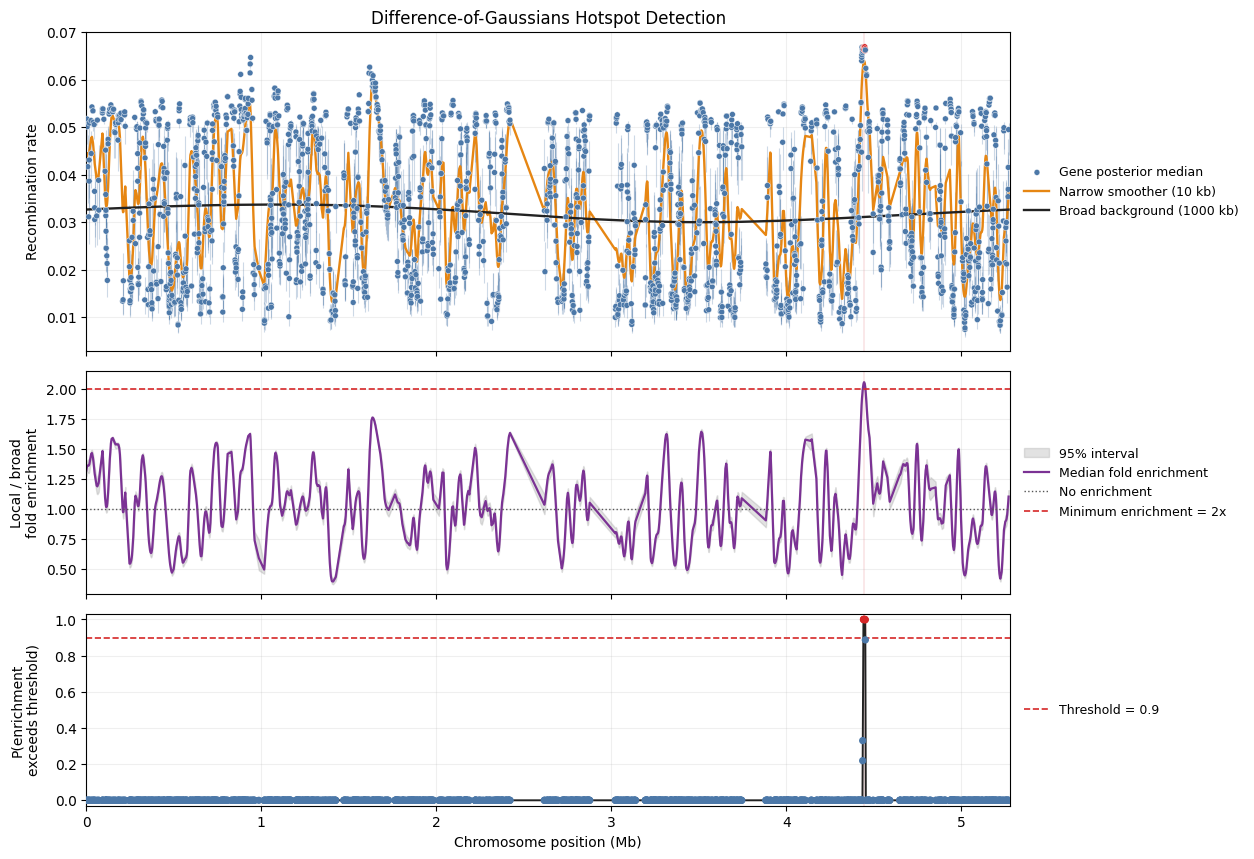

In [34]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 0].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=10_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=2.0,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=5280085
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Recombination rate",
    save_path="../output/klebsiella_local_recomb_dog.pdf"
)
plt.show()

In [35]:
recomb_hotspots = pd.DataFrame(index=range(len(result.segments(max_gap_bp=800_000))),
                               columns=['start_position_bp',
                                        'end_position_bp',
                                        'n_genes',
                                        'peak_probability',
                                        'peak_fold_enrichment'])
recomb_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,NaN,NaN,NaN,NaN,NaN


In [36]:
positions_end = gene_ends[ord_start_pos]
for i in range(len(result.segments(max_gap_bp=800_000))):
    segment = result.segments(max_gap_bp=800_000)[i]
    pos_start_index = segment['start_index']
    pos_end_index = segment['end_index']
    recomb_hotspots.loc[i, 'start_position_bp'] = positions[pos_start_index]
    recomb_hotspots.loc[i, 'end_position_bp'] = positions_end[pos_end_index]
    recomb_hotspots.loc[i, 'n_genes'] = segment['n_genes']
    recomb_hotspots.loc[i, 'peak_probability'] = segment['peak_probability']
    recomb_hotspots.loc[i, 'peak_fold_enrichment'] = segment['peak_fold_enrichment']

recomb_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,4441317,4459413,8,1.0,2.056771


Detected hotspot segments:
  0.03-0.05 Mb; 5 genes; peak P=1.000; peak enrichment=2.17x
  0.07-0.10 Mb; 7 genes; peak P=1.000; peak enrichment=2.27x
  0.13-0.16 Mb; 7 genes; peak P=1.000; peak enrichment=2.60x
  0.80-0.81 Mb; 4 genes; peak P=1.000; peak enrichment=2.66x
  0.91-0.95 Mb; 15 genes; peak P=1.000; peak enrichment=4.64x
  1.07-1.10 Mb; 17 genes; peak P=1.000; peak enrichment=3.16x
  1.62-1.73 Mb; 47 genes; peak P=1.000; peak enrichment=6.03x
  4.14-4.15 Mb; 4 genes; peak P=1.000; peak enrichment=2.66x
  4.42-4.45 Mb; 22 genes; peak P=1.000; peak enrichment=8.33x
  4.52-4.52 Mb; 1 genes; peak P=0.979; peak enrichment=2.07x
  4.55-4.59 Mb; 14 genes; peak P=1.000; peak enrichment=2.96x
  4.69-4.70 Mb; 5 genes; peak P=0.999; peak enrichment=2.15x
  4.74-4.75 Mb; 7 genes; peak P=1.000; peak enrichment=2.53x


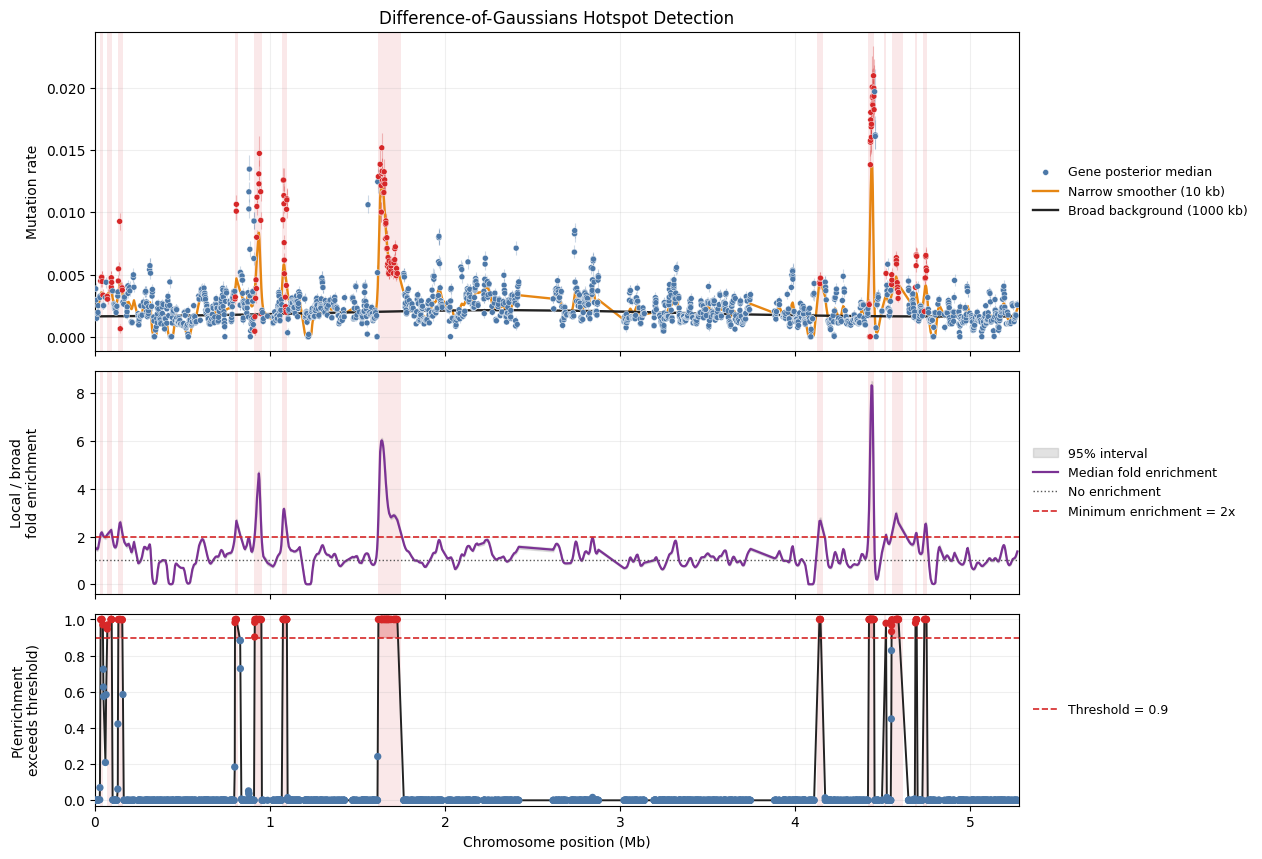

In [37]:
positions = gene_starts[ord_start_pos]
posterior_draws = theta_post[ord_start_pos, :, 1].transpose()
indices_below_zero = np.where(posterior_draws <= 0)
posterior_draws[indices_below_zero] = np.finfo(np.float64).eps

detector = DoGHotspotDetector(
    narrow_bandwidth_bp=10_000,
    broad_bandwidth_bp=1_000_000,
    min_fold_enrichment=2.0,
    probability_threshold=0.90,
    residual_log_sd=0.20,
    min_effective_genes=1.0,
    random_state=10,
    chromosome_length_bp=5280085
)
result = detector.fit(positions, posterior_draws)

print("Detected hotspot segments:")
for segment in result.segments(max_gap_bp=800_000):
    print(
        f"  {segment['start_position_bp'] / 1e6:.2f}-"
        f"{segment['end_position_bp'] / 1e6:.2f} Mb; "
        f"{segment['n_genes']} genes; "
        f"peak P={segment['peak_probability']:.3f}; "
        f"peak enrichment={segment['peak_fold_enrichment']:.2f}x"
    )

result.plot(
    rate_label="Mutation rate",
    save_path="../output/klebsiella_local_mutate_dog.pdf"
)
plt.show()

In [38]:
mutate_hotspots = pd.DataFrame(index=range(len(result.segments(max_gap_bp=800_000))),
                               columns=['start_position_bp',
                                        'end_position_bp',
                                        'n_genes',
                                        'peak_probability',
                                        'peak_fold_enrichment'])
mutate_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


In [39]:
positions_end = gene_ends[ord_start_pos]
for i in range(len(result.segments(max_gap_bp=800_000))):
    segment = result.segments(max_gap_bp=800_000)[i]
    pos_start_index = segment['start_index']
    pos_end_index = segment['end_index']
    mutate_hotspots.loc[i, 'start_position_bp'] = positions[pos_start_index]
    mutate_hotspots.loc[i, 'end_position_bp'] = positions_end[pos_end_index]
    mutate_hotspots.loc[i, 'n_genes'] = segment['n_genes']
    mutate_hotspots.loc[i, 'peak_probability'] = segment['peak_probability']
    mutate_hotspots.loc[i, 'peak_fold_enrichment'] = segment['peak_fold_enrichment']

mutate_hotspots

,start_position_bp,end_position_bp,n_genes,peak_probability,peak_fold_enrichment
0,32570,55167,5,1.0,2.174929
1,70612,103656,7,1.0,2.273841
2,133663,164703,7,1.0,2.595895
3,800162,836597,4,1.0,2.657344
4,912652,958873,15,1.0,4.641974
5,1074172,1104496,17,1.0,3.158506
6,1619590,1771599,47,1.0,6.02582
7,4139899,4179732,4,1.0,2.660483
8,4422958,4460347,22,1.0,8.333415
9,4520339,4529632,1,0.979,2.072547


In [40]:
with pd.ExcelWriter('../output/klebsiella_hotspots.xlsx') as writer:
    recomb_hotspots.to_excel(writer, sheet_name='Recombination', index=False)
    mutate_hotspots.to_excel(writer, sheet_name='Mutation', index=False)